In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import torch
from cycler import cycler
import importlib
import logging

import sys
PROJECT_DIR = "/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER"
SRC_DIR = str(Path(PROJECT_DIR) / "src")
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)
    
DEV_DIR = str(Path(PROJECT_DIR) / "dev")
if DEV_DIR not in sys.path:
    sys.path.insert(0, DEV_DIR)
    
import muon_preprocessing as muon_prep
import multiomic_transformer.utils.data_formatter as data_formatter
import multiomic_transformer.utils.experiment_handler as experiment_handler

random.seed(1337)
np.random.seed(1337)
torch.manual_seed(1337)

logging.basicConfig(level=logging.INFO, format='%(message)s')

GROUND_TRUTH_DIR = Path(PROJECT_DIR) / "data" / "ground_truth_files"

EXPERIMENT_DIR = Path("/gpfs/Labs/Uzun/DATA/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/EXPERIMENTS/SCALABILITY")
PROCESSED_DATA_DIR = Path("/gpfs/Labs/Uzun/DATA/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/PROCESSED_DATA/SCALABILITY")
RAW_DATA_DIR = Path("/gpfs/Labs/Uzun/DATA/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/SCALABILITY_PROCESSED_DATASETS")

### Set the color palette

In [3]:
color_palette = {
  "blue_light": "#18A6ED",
  "orange_light": "#EEA700",
  "red_light": "#EF767A",
  "green_light": "#7EE3BA",
  "purple_light": "#C798CC",
  "grey_light": "#BCBCBF",
  "blue_dark": "#2E70B9",
  "orange_dark": "#D18A3D",
  "red_dark": "#BC3E1A",
  "green_dark": "#32936F",
  "purple_dark": "#9D5ED4",
  "grey_dark": "#434B4E",
}

plt.rcParams.update({

    # figure
    "figure.figsize": (6,4),
    "figure.dpi": 300,

    # fonts
    "font.size": 12,
    "axes.titlesize": 16,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,

    # axes
    "axes.spines.top": True,
    "axes.spines.right": True,
    "axes.grid": False,
    "grid.alpha": 0.25,

    # lines
    "lines.linewidth": 2,

    # legend
    "legend.frameon": False,

    # color cycle
    "axes.prop_cycle": cycler(color=color_palette.values()),
})

method_color_dict = {
  "Gradient Attribution": "#4195DF",
  "LINGER": "#7EE3BA",
  "SCENIC+": "#EF767A",
  "CellOracle": "#F9C60D",
  "Pando": "#EF9CFA",
  "TRIPOD": "#82EC32",
  "FigR": "#FDA7BB",
  "GRaNIE": "#F98637"
}

light_colors = [v for k,v in color_palette.items() if "light" in k]

order = ["Gradient Attribution", "LINGER", "SCENIC+", "CellOracle", "GRaNIE", "Pando", "TRIPOD", "FigR"]

## Load Ground Truth

In [4]:
def load_ground_truth(ground_truth_file: str|Path):
    if type(ground_truth_file) == str:
        ground_truth_file = Path(ground_truth_file)
        
    if ground_truth_file.suffix == ".csv":
        sep = ","
    elif ground_truth_file.suffix == ".tsv":
        sep="\t"
        
    ground_truth_df = pd.read_csv(ground_truth_file, sep=sep, on_bad_lines="skip", engine="python")
    
    if "chip" in ground_truth_file.name and "atlas" in ground_truth_file.name:
        ground_truth_df = ground_truth_df[["source_id", "target_id"]]

    if ground_truth_df.columns[0] != "Source" or ground_truth_df.columns[1] != "Target":
        ground_truth_df = ground_truth_df.rename(columns={ground_truth_df.columns[0]: "Source", ground_truth_df.columns[1]: "Target"})
    ground_truth_df["Source"] = ground_truth_df["Source"].astype(str).str.upper()
    ground_truth_df["Target"] = ground_truth_df["Target"].astype(str).str.upper()
    
    # Build TF, TG, and edge sets for quick lookup later
    gt = ground_truth_df[["Source", "Target"]].dropna()

    gt_tfs = set(gt["Source"].unique())
    gt_tgs = set(gt["Target"].unique())
    
    gt_pairs = (gt["Source"] + "\t" + gt["Target"]).drop_duplicates()
    
    gt_lookup = (gt_tfs, gt_tgs, set(gt_pairs))
        
    return ground_truth_df, gt_lookup

gt_by_dataset_dict = {
    "Macrophage": {
        # "RN204": load_ground_truth(GROUND_TRUTH_DIR / "rn204_macrophage_human_chipseq.tsv"),
        "ChIP-Atlas macrophage": load_ground_truth(GROUND_TRUTH_DIR / "chipatlas_macrophage.csv"),
        "Perturb-seq macrophage": load_ground_truth(GROUND_TRUTH_DIR / "macrophage_perturbations.csv"),
    },
    "mESC": {
        "ChIP-Atlas mESC": load_ground_truth(GROUND_TRUTH_DIR / "chip_atlas_tf_peak_tg_dist.csv"),
        "RN111": load_ground_truth(GROUND_TRUTH_DIR / "RN111.tsv"),
        "RN112": load_ground_truth(GROUND_TRUTH_DIR / "RN112.tsv"),
        "RN114": load_ground_truth(GROUND_TRUTH_DIR / "RN114.tsv"),
        "RN116": load_ground_truth(GROUND_TRUTH_DIR / "RN116.tsv"),        
    },
    "K562": {
        "ChIP-Atlas K562": load_ground_truth(GROUND_TRUTH_DIR / "chipatlas_K562.csv"),
        "RN117": load_ground_truth(GROUND_TRUTH_DIR / "RN117.tsv"),        
    },
    "iPSC": {
        # "ChIP-Atlas iPSC": load_ground_truth(GROUND_TRUTH_DIR / "chipatlas_iPSC.csv"),
        "ChIP-Atlas iPSC (1 Mb)": load_ground_truth(GROUND_TRUTH_DIR / "chipatlas_iPSC_1mb.csv"),
        # "ChIP-Atlas iPSC (100 kb)": load_ground_truth(GROUND_TRUTH_DIR / "chipatlas_iPSC_100kb.csv"),
    }
}

In [7]:

cell_type = "mESC"
sample_name = "E7.5"
experiment_suffix = "cell_scalability"

experiment_dict = {}

for cell_num in [1000, 2000, 3000, 4000, 5000]:
    experiment_name = f"{cell_type}_{sample_name}_{cell_num}_{experiment_suffix}"
    
    exp = experiment_handler.load_experiment_handler(
        tdf_settings_path=PROCESSED_DATA_DIR / experiment_name / "settings.json",
        experiment_dir=EXPERIMENT_DIR,
        model_num=1,
        verbose=False,
        )

    experiment_dict[cell_num] = exp
    
print(experiment_dict[1000].experiment_name)

mESC_E7.5_1000_cell_scalability: Loaded existing settings
mESC_E7.5_2000_cell_scalability: Loaded existing settings
mESC_E7.5_3000_cell_scalability: Loaded existing settings
mESC_E7.5_4000_cell_scalability: Loaded existing settings
mESC_E7.5_5000_cell_scalability: Loaded existing settings


mESC_E7.5_1000_cell_scalability


In [8]:
gt_by_dataset_dict_sample = gt_by_dataset_dict[cell_type]
for cell_num, exp in experiment_dict.items():
    exp.load_grn()
    exp.calculate_auroc_all_methods(
        exp.tdf.sample_names, 
        cell_type, 
        gt_by_dataset_dict_sample, 
        grn=exp.grn,
        use_muon_grn=True
    )


Processing sample: E7.5_rep1 | Dataset: mESC
  - Loading SCENIC+
  - Loading LINGER
  - Loading CellOracle

Evaluating pooled methods across samples
  - Evaluating SCENIC+
  - Evaluating LINGER
  - Evaluating CellOracle
  - Evaluating Gradient Attribution
method
LINGER                  0.549797
Gradient Attribution    0.535482
CellOracle              0.527437
SCENIC+                 0.479267
Name: auroc, dtype: float64

Per-TF evaluation of pooled methods across samples
  - Per-TF evaluating SCENIC+
  - Per-TF evaluating LINGER
  - Per-TF evaluating CellOracle
  - Per-TF evaluating Gradient Attribution
method
CellOracle              0.578307
Gradient Attribution    0.546668
LINGER                  0.536276
SCENIC+                 0.478031
Name: median_per_tf_auroc, dtype: float64

Processing sample: E7.5_rep1 | Dataset: mESC
  - Loading SCENIC+
  - Loading LINGER
  - Loading CellOracle

Evaluating pooled methods across samples
  - Evaluating SCENIC+
  - Evaluating LINGER
  - Evaluatin

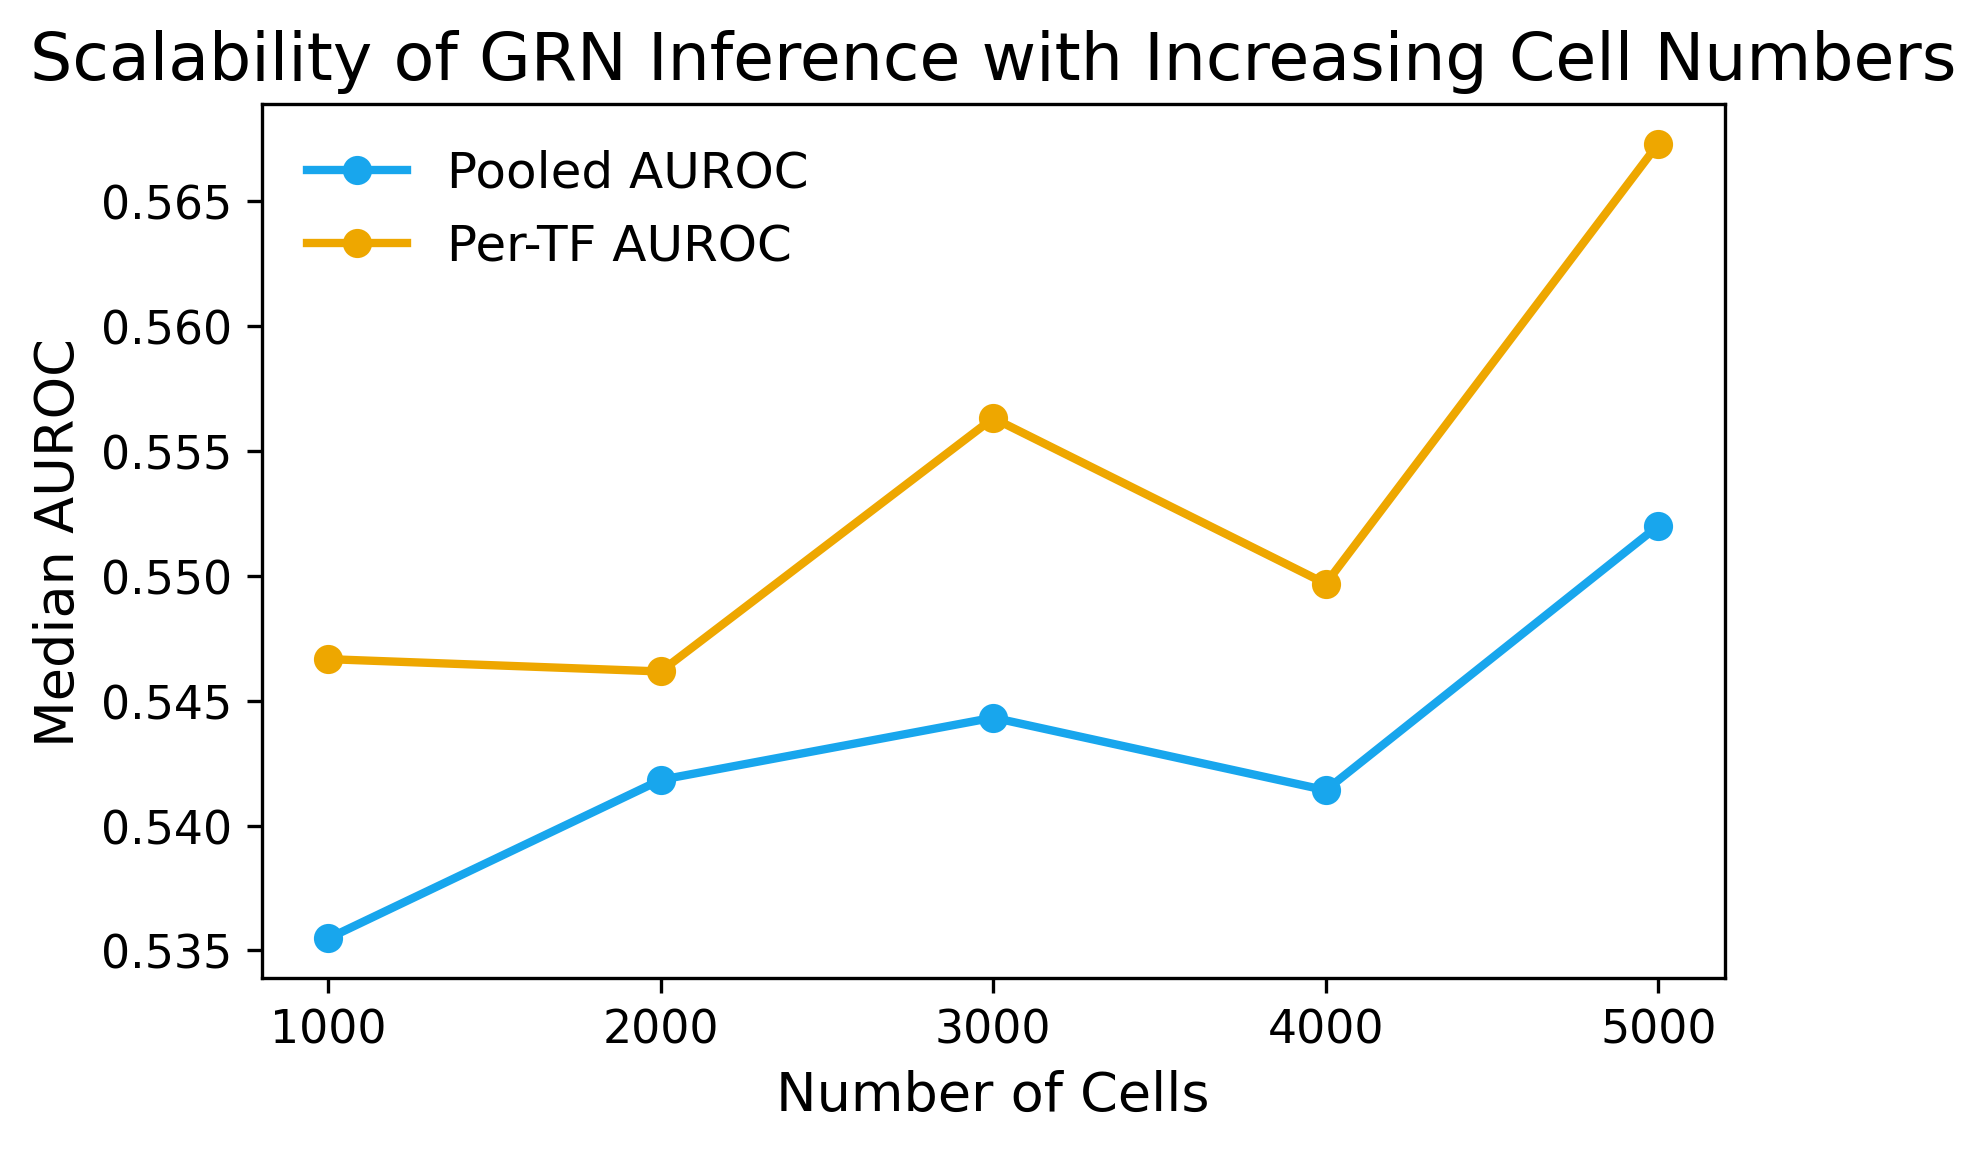

In [10]:

pooled_auroc_results_by_cell_num = {}
per_tf_auroc_results_by_cell_num = {}

for cell_num, exp in experiment_dict.items():
    per_tf_df_all =  pd.read_csv(exp.model_training_dir / "per_tf_auroc_auprc_results.csv")
    pooled_df_all = pd.read_csv(exp.model_training_dir / "pooled_auroc_auprc_results.csv")

    per_tf_plot_df = (
        per_tf_df_all.dropna(subset=["auroc"])
        .groupby(['method', 'gt'], as_index=False)
        .agg(
            auroc=('auroc', 'median'),
        )
    )

    pooled_df_median_auroc = pooled_df_all[pooled_df_all["method"] == "Gradient Attribution"]["auroc"].median()
    per_tf_median_auroc = per_tf_plot_df[per_tf_plot_df["method"] == "Gradient Attribution"]["auroc"].median()
    
    pooled_auroc_results_by_cell_num[cell_num] = pooled_df_median_auroc
    per_tf_auroc_results_by_cell_num[cell_num] = per_tf_median_auroc
    
plt.figure(figsize=(6, 4))
plt.plot(list(pooled_auroc_results_by_cell_num.keys()), list(pooled_auroc_results_by_cell_num.values()), marker='o', label="Pooled AUROC")
plt.plot(list(per_tf_auroc_results_by_cell_num.keys()), list(per_tf_auroc_results_by_cell_num.values()), marker='o', label="Per-TF AUROC")
plt.xlabel("Number of Cells")
plt.ylabel("Median AUROC")
plt.xticks([1000, 2000, 3000, 4000, 5000])
plt.title("Scalability of GRN Inference with Increasing Cell Numbers")
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()

In [ ]:

pooled_auroc_results_by_cell_num = {}
per_tf_auroc_results_by_cell_num = {}

for cell_num, exp in experiment_dict.items():
    
    
    pooled_auroc_results_by_cell_num[cell_num] = pooled_df_median_auroc
    per_tf_auroc_results_by_cell_num[cell_num] = per_tf_median_auroc
    
plt.figure(figsize=(6, 4))
plt.plot(list(pooled_auroc_results_by_cell_num.keys()), list(pooled_auroc_results_by_cell_num.values()), marker='o', label="Pooled AUROC")
plt.plot(list(per_tf_auroc_results_by_cell_num.keys()), list(per_tf_auroc_results_by_cell_num.values()), marker='o', label="Per-TF AUROC")
plt.xlabel("Number of Cells")
plt.ylabel("Median AUROC")
plt.xticks([1000, 2000, 3000, 4000, 5000])
plt.title("Scalability of GRN Inference with Increasing Cell Numbers")
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()